# HATRec × Cosmos 3 — Response & Runtime Insight Analysis

Notebook này phân tích kết quả Cosmos 3 trên HATRec theo ba lớp: **khả năng hoàn tất reasoning**, **khả năng trả đúng label**, và **chất lượng report evidence-grounded**.

Quy ước:
- `normal`: model trả report hoàn chỉnh trước watchdog.
- `thinking_too_long`: quá 15 giây nhưng đã thu được một phần reasoning/report.
- `thinking_too_long_no_output`: quá 15 giây và chưa thu được nội dung hữu ích.
- Accuracy có hai dạng: **conditional accuracy** trên prediction parse được và **end-to-end accuracy** trên toàn bộ video đã thử.

In [ ]:
# One-time ABI repair for this Python 3.10 kernel.
# pandas 2.1 / pyarrow 15 / matplotlib 3.7 in this environment require NumPy 1.x.
import importlib.metadata as _metadata
import subprocess as _subprocess
import sys as _sys

_numpy_version = _metadata.version('numpy')
if int(_numpy_version.split('.')[0]) >= 2:
    print(f'NumPy {_numpy_version} is ABI-incompatible with the installed analysis stack.')
    print('Installing NumPy 1.26.4 once; the kernel will restart automatically...')
    _subprocess.check_call([_sys.executable, '-m', 'pip', 'install', '--quiet', '--no-cache-dir', '--force-reinstall', 'numpy==1.26.4'])
    get_ipython().kernel.do_shutdown(restart=True)
else:
    print('Dependency ABI OK — NumPy', _numpy_version)


Dependency ABI OK — NumPy 1.26.4


In [ ]:
from pathlib import Path
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)

ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / 'research' / 'hatrec_cosmos3',
    Path('/content/hatrec_cosmos3'),
    Path('/content/mini-world-model/research/hatrec_cosmos3'),
]
ROOT = next((p for p in ROOT_CANDIDATES if (p/'outputs'/'ui_reports').exists()), None)
assert ROOT is not None, 'Không tìm thấy outputs/ui_reports. Hãy sửa ROOT_CANDIDATES.'
REPORT_ROOT = ROOT / 'outputs' / 'ui_reports'
ANALYSIS_ROOT = ROOT / 'outputs' / 'analysis'
ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
LOG_FILES = sorted((ROOT/'outputs').glob('ui_run*.log'))
LOG_PATH = LOG_FILES[-1] if LOG_FILES else None
print('ROOT:', ROOT)
print('JSON reports:', len(list(REPORT_ROOT.rglob('*.json'))))
print('Markdown reports:', len(list(REPORT_ROOT.rglob('*.md'))))
print('Runtime log:', LOG_PATH)

ROOT: c:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\hatrec_cosmos3
JSON reports: 546
Markdown reports: 546
Runtime log: c:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\hatrec_cosmos3\outputs\ui_run_68.log


In [ ]:
TASK_NAMES = {
    0: 'Assembling the spring',
    1: 'Placing white plastic',
    2: 'Screwing-1',
    3: 'Inflating valve',
    4: 'Placing black plastic',
    5: 'Screwing-2',
    6: 'Fixing cable',
}
PHRASE_TO_TASK = [
    (r'screwing[- ]?2', 5), (r'screwing[- ]?1', 2),
    (r'assembling (?:the )?spring|spring assembly', 0),
    (r'placing (?:the )?white plastic', 1),
    (r'inflating (?:the )?valve|valve inflation', 3),
    (r'placing (?:the )?black plastic', 4),
    (r'fixing (?:the )?cable|cable fixing', 6),
]
SECTIONS = [
    'VIDEO OVERVIEW', 'TEMPORAL OBSERVATIONS', 'VISIBLE OBJECTS AND WORK AREA',
    'OPERATOR ACTIONS', 'ACTION SEQUENCE', 'CURRENT ASSEMBLY STATE',
    'POSSIBLE ANOMALIES OR SAFETY CONCERNS', 'MOST LIKELY HATREC TASK',
    'CONFIDENCE AND LIMITATIONS'
]

def clean_report(text):
    text = text or ''
    try:
        if 'â€' in text or 'Â©' in text:
            text = text.encode('latin1').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        pass
    text = re.split(r'\nTerms of Use\n|\nPrivacy Policy\n', text, maxsplit=1)[0]
    return text.strip()

def extract_prediction(text):
    text = clean_report(text)
    focus = text
    marker = re.search(r'MOST LIKELY HATREC TASK', text, re.I)
    if marker:
        focus = text[marker.end():]
        focus = re.split(r'CONFIDENCE AND LIMITATIONS', focus, maxsplit=1, flags=re.I)[0]
    numeric = re.search(r'(?:task|answer(?: is)?)\s*[:#-]?\s*([0-6])\b', focus, re.I)
    if numeric:
        return int(numeric.group(1))
    for pattern, task in PHRASE_TO_TASK:
        if re.search(pattern, focus, re.I):
            return task
    return None

def extract_confidence(text):
    matches = re.findall(r'confidence[^\n%]{0,80}?([0-9]{1,3}(?:\.[0-9]+)?)\s*%', text or '', re.I)
    return min(float(matches[-1]), 100.0)/100.0 if matches else np.nan

def runtime_class(completion, report):
    if completion in {'complete', 'complete_spinner_stuck'}:
        return 'normal'
    if completion == 'partial_timeout' and len(clean_report(report)) >= 100:
        return 'thinking_too_long'
    if completion == 'timeout_no_output' or len(clean_report(report)) < 100:
        return 'thinking_too_long_no_output'
    return 'error_or_unknown'

def parse_run_index(name):
    m = re.search(r'sample_(\d+)\.mp4', name or '')
    return int(m.group(1)) if m else np.nan

In [ ]:
rows = []
for path in sorted(REPORT_ROOT.rglob('*.json')):
    try:
        rec = json.loads(path.read_text(encoding='utf-8'))
    except Exception as exc:
        rows.append({'path': str(path), 'status': 'invalid_json', 'error': str(exc)})
        continue
    sample_id = rec.get('sample_id', path.stem)
    truth_match = re.search(r'_task_([0-6])$', sample_id, re.I)
    truth = int(truth_match.group(1)) if truth_match else np.nan
    md_path = path.with_suffix('.md')
    md_text = md_path.read_text(encoding='utf-8', errors='replace') if md_path.exists() else ''
    report = clean_report(rec.get('report') or md_text)
    prediction = extract_prediction(report)
    completion = rec.get('completion', rec.get('status', 'unknown'))
    section_count = sum(section in report.upper() for section in SECTIONS)
    rows.append({
        'sample_id': sample_id, 'path': str(path), 'truth': truth,
        'truth_name': TASK_NAMES.get(truth), 'prediction': prediction,
        'prediction_name': TASK_NAMES.get(prediction), 'status': rec.get('status'),
        'completion': completion, 'runtime_class': runtime_class(completion, report),
        'latency_seconds': rec.get('latency_seconds', np.nan),
        'run_index': parse_run_index(rec.get('uploaded_filename')),
        'report': report, 'response_chars': len(report),
        'response_words': len(report.split()), 'section_count': section_count,
        'full_format': section_count == len(SECTIONS),
        'evidence_tags': sum(len(re.findall(rf'\b{x}\b', report, re.I)) for x in ['OBSERVED','INFERRED','UNKNOWN']),
        'confidence': extract_confidence(report),
    })

df = pd.DataFrame(rows).sort_values(['run_index', 'sample_id'], na_position='last').reset_index(drop=True)
df['parseable'] = df['prediction'].notna()
df['correct'] = df['parseable'] & (df['prediction'] == df['truth'])
df['evidence_tag_compliant'] = df['evidence_tags'] > 0
display(df[['sample_id','truth_name','prediction_name','runtime_class','latency_seconds','response_words','section_count']].head(10))
print('Loaded', len(df), 'attempted videos')

,sample_id,truth_name,prediction_name,runtime_class,latency_seconds,response_words,section_count
0,Cycle_0\Cycle_0_task_0,Assembling the spring,Screwing-1,thinking_too_long,16.263,180,0
1,Cycle_0\Cycle_0_task_1,Placing white plastic,Placing black plastic,normal,14.257,284,9
2,Cycle_0\Cycle_0_task_2,Screwing-1,Placing white plastic,thinking_too_long_no_output,16.244,5,0
3,Cycle_0\Cycle_0_task_3,Inflating valve,Assembling the spring,thinking_too_long,16.416,423,9
4,Cycle_0\Cycle_0_task_4,Placing black plastic,Placing white plastic,thinking_too_long,16.255,352,9
5,Cycle_0\Cycle_0_task_5,Screwing-2,None,thinking_too_long,16.211,896,0
6,Cycle_0\Cycle_0_task_6,Fixing cable,Placing black plastic,thinking_too_long,16.254,408,9
7,Cycle_1\Cycle_1_task_0,Assembling the spring,None,thinking_too_long,16.222,230,0
8,Cycle_1\Cycle_1_task_1,Placing white plastic,None,thinking_too_long,16.239,115,2
9,Cycle_1\Cycle_1_task_2,Screwing-1,Screwing-1,thinking_too_long,16.255,365,9


Loaded 546 attempted videos


In [ ]:
attempted = len(df)
normal_n = int((df.runtime_class == 'normal').sum())
too_long_n = int(df.runtime_class.str.startswith('thinking_too_long').sum())
parseable_n = int(df.parseable.sum())
correct_n = int(df.correct.sum())
conditional_acc = correct_n / parseable_n if parseable_n else np.nan
e2e_acc = correct_n / attempted if attempted else np.nan
summary = pd.DataFrame({
    'Metric': ['Attempted','Normal completion','Thinking >15s','Parseable prediction','Correct','Conditional accuracy','End-to-end accuracy','Full 9-section format','Evidence-tag compliance'],
    'Value': [attempted, normal_n, too_long_n, parseable_n, correct_n, conditional_acc, e2e_acc, df.full_format.mean(), df.evidence_tag_compliant.mean()]
})
display(summary.style.format({'Value': lambda x: f'{x:.1%}' if isinstance(x, float) and x <= 1 else f'{x:.2f}' if isinstance(x, float) else str(x)}))

coverage = df.groupby(['truth','truth_name'], dropna=False).agg(
    attempted=('sample_id','size'), normal=('runtime_class', lambda s: (s=='normal').sum()),
    too_long=('runtime_class', lambda s: s.str.startswith('thinking_too_long').sum()),
    parseable=('parseable','sum'), correct=('correct','sum'), mean_latency=('latency_seconds','mean')
).reset_index()
coverage['parse_coverage'] = coverage.parseable / coverage.attempted
coverage['e2e_accuracy'] = coverage.correct / coverage.attempted
coverage['conditional_accuracy'] = coverage.correct / coverage.parseable.replace(0, np.nan)
display(coverage.round(3))

,Metric,Value
0,Attempted,546.00
1,Normal completion,125.00
2,Thinking >15s,421.00
3,Parseable prediction,449.00
4,Correct,129.00
5,Conditional accuracy,28.7%
6,End-to-end accuracy,23.6%
7,Full 9-section format,65.9%
8,Evidence-tag compliance,36.3%


,truth,truth_name,attempted,normal,too_long,parseable,correct,mean_latency,parse_coverage,e2e_accuracy,conditional_accuracy
0,0,Assembling the spring,78,29,49,62,1,16.195,0.795,0.013,0.016
1,1,Placing white plastic,78,24,54,60,19,16.253,0.769,0.244,0.317
2,2,Screwing-1,78,16,62,66,37,16.559,0.846,0.474,0.561
3,3,Inflating valve,78,22,56,67,0,16.377,0.859,0.000,0.000
4,4,Placing black plastic,78,26,52,68,42,16.284,0.872,0.538,0.618
5,5,Screwing-2,78,2,76,60,22,16.923,0.769,0.282,0.367
6,6,Fixing cable,78,6,72,66,8,16.846,0.846,0.103,0.121


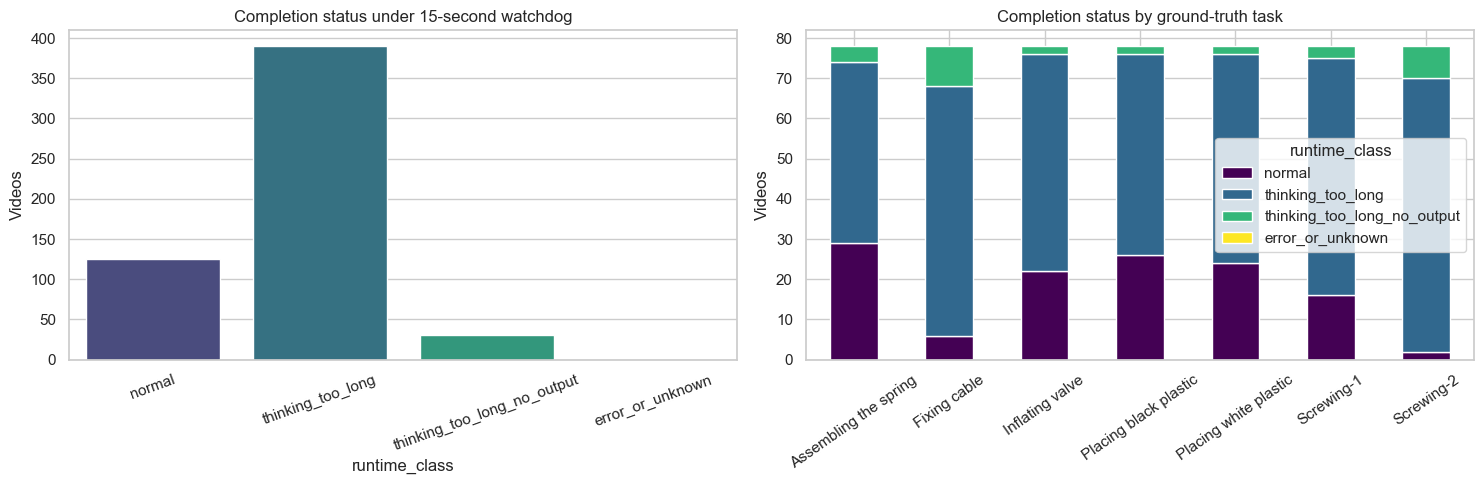

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = ['normal','thinking_too_long','thinking_too_long_no_output','error_or_unknown']
counts = df.runtime_class.value_counts().reindex(order, fill_value=0)
sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Completion status under 15-second watchdog')
axes[0].set_ylabel('Videos'); axes[0].tick_params(axis='x', rotation=20)
status_by_task = pd.crosstab(df.truth_name, df.runtime_class).reindex(columns=order, fill_value=0)
status_by_task.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Completion status by ground-truth task')
axes[1].set_xlabel(''); axes[1].set_ylabel('Videos'); axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'completion_status.png', dpi=160, bbox_inches='tight'); plt.show()

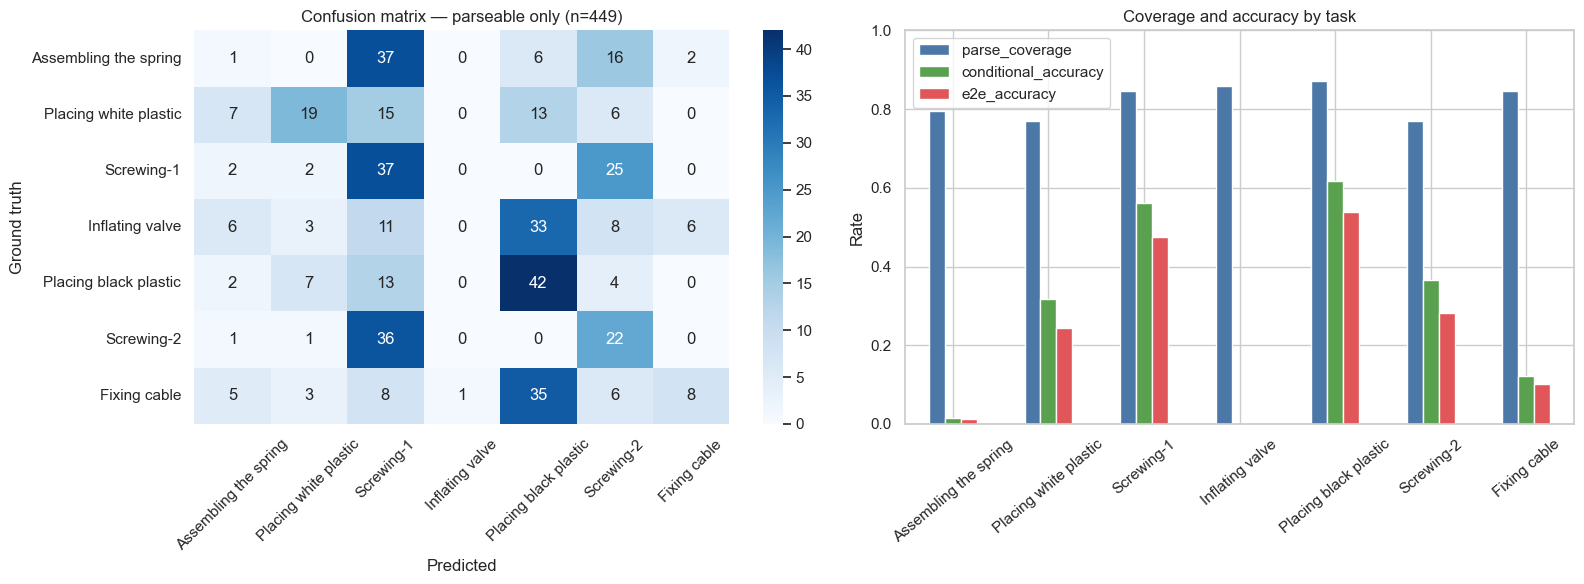

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm = pd.crosstab(df.loc[df.parseable,'truth'], df.loc[df.parseable,'prediction'])
cm = cm.reindex(index=range(7), columns=range(7), fill_value=0)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[TASK_NAMES[i] for i in range(7)], yticklabels=[TASK_NAMES[i] for i in range(7)])
axes[0].set_title(f'Confusion matrix — parseable only (n={parseable_n})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Ground truth')
axes[0].tick_params(axis='x', rotation=45); axes[0].tick_params(axis='y', rotation=0)
plot_cov = coverage.set_index('truth_name')[['parse_coverage','conditional_accuracy','e2e_accuracy']]
plot_cov.plot(kind='bar', ax=axes[1], ylim=(0,1), color=['#4c78a8','#59a14f','#e15759'])
axes[1].set_title('Coverage and accuracy by task')
axes[1].set_xlabel(''); axes[1].set_ylabel('Rate'); axes[1].tick_params(axis='x', rotation=40)
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'classification_metrics.png', dpi=160, bbox_inches='tight'); plt.show()

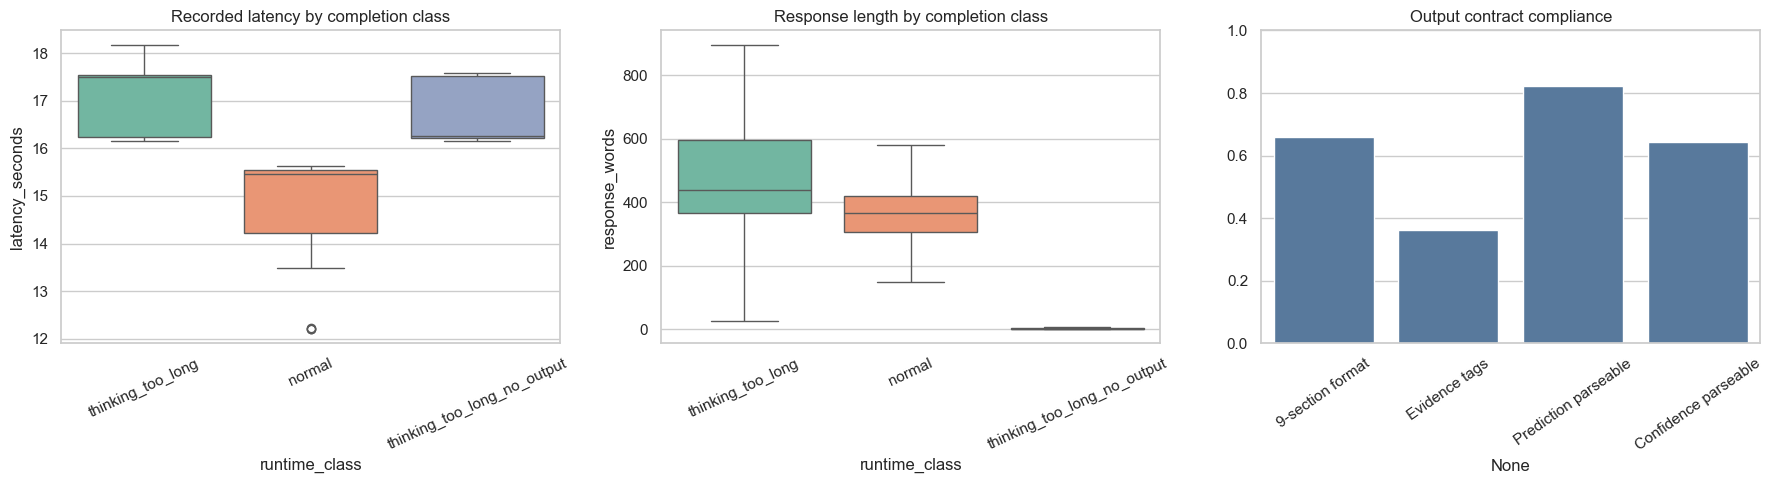

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='runtime_class', y='latency_seconds', ax=axes[0], palette='Set2')
axes[0].set_title('Recorded latency by completion class'); axes[0].tick_params(axis='x', rotation=25)
sns.boxplot(data=df, x='runtime_class', y='response_words', ax=axes[1], palette='Set2', showfliers=False)
axes[1].set_title('Response length by completion class'); axes[1].tick_params(axis='x', rotation=25)
quality = pd.Series({
    '9-section format': df.full_format.mean(),
    'Evidence tags': df.evidence_tag_compliant.mean(),
    'Prediction parseable': df.parseable.mean(),
    'Confidence parseable': df.confidence.notna().mean(),
})
sns.barplot(x=quality.index, y=quality.values, ax=axes[2], color='#4c78a8')
axes[2].set_ylim(0,1); axes[2].set_title('Output contract compliance'); axes[2].tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'latency_and_quality.png', dpi=160, bbox_inches='tight'); plt.show()

,run_index,total_target,video,log_completion,log_seconds,cumulative_inference_minutes
60,61,546,Cycle_16_task_4.mp4,partial_timeout,17.7,16.400000
61,62,546,Cycle_16_task_5.mp4,partial_timeout,17.6,16.693333
62,63,546,Cycle_16_task_6.mp4,partial_timeout,17.5,16.985000
63,64,546,Cycle_17_task_0.mp4,complete,15.6,17.245000
64,65,546,Cycle_17_task_1.mp4,partial_timeout,17.4,17.535000


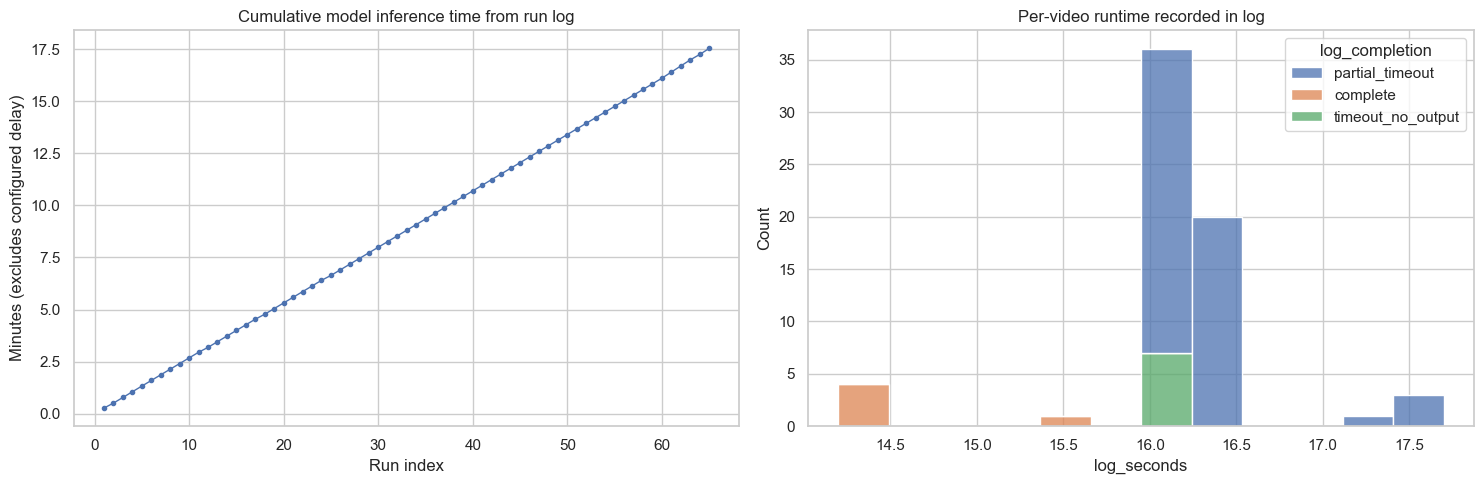

In [ ]:
log_rows = []
if LOG_PATH and LOG_PATH.exists():
    runs = {}
    for line in LOG_PATH.read_text(encoding='utf-8', errors='replace').splitlines():
        m = re.search(r'\[\s*(\d+)/(\d+)\] RUN (.+?\.mp4)', line)
        if m:
            runs[int(m.group(1))] = {'run_index': int(m.group(1)), 'total_target': int(m.group(2)), 'video': m.group(3)}
            continue
        m = re.search(r'\[\s*(\d+)/(\d+)\] (COMPLETE|PARTIAL_TIMEOUT|TIMEOUT_NO_OUTPUT)\s+([0-9.]+)s', line)
        if m:
            idx = int(m.group(1)); row = runs.setdefault(idx, {'run_index': idx})
            row.update({'log_completion': m.group(3).lower(), 'log_seconds': float(m.group(4))})
    log_df = pd.DataFrame(runs.values()).sort_values('run_index')
    log_df['cumulative_inference_minutes'] = log_df.log_seconds.fillna(0).cumsum()/60
    display(log_df.tail())
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(log_df.run_index, log_df.cumulative_inference_minutes, marker='.', linewidth=1)
    axes[0].set_title('Cumulative model inference time from run log')
    axes[0].set_xlabel('Run index'); axes[0].set_ylabel('Minutes (excludes configured delay)')
    sns.histplot(data=log_df, x='log_seconds', hue='log_completion', multiple='stack', bins=12, ax=axes[1])
    axes[1].set_title('Per-video runtime recorded in log')
    plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'runtime_log.png', dpi=160, bbox_inches='tight'); plt.show()
else:
    log_df = pd.DataFrame()
    print('Không tìm thấy ui_run*.log; các biểu đồ còn lại vẫn chạy từ JSON metadata.')

In [ ]:
misclassified = df[df.parseable & ~df.correct][['sample_id','truth_name','prediction_name','runtime_class','confidence','report']]
timeouts = df[df.runtime_class.str.startswith('thinking_too_long')][['sample_id','truth_name','runtime_class','response_words','report']]
display(Markdown('### Misclassified examples'))
display(misclassified.drop(columns='report').head(20))
display(Markdown('### Thinking-too-long examples'))
display(timeouts.drop(columns='report').head(20))

def show_report(sample_id):
    hit = df[df.sample_id == sample_id]
    if hit.empty:
        print('Sample not found:', sample_id); return
    row = hit.iloc[0]
    display(Markdown(f"## {row.sample_id}\n**GT:** {row.truth_name}  \n**Pred:** {row.prediction_name}  \n**Runtime:** {row.runtime_class}, {row.latency_seconds:.2f}s\n\n---\n\n{row.report}"))

# Ví dụ: bỏ comment và thay sample_id để đọc report đầy đủ.
# show_report('Cycle_17\\Cycle_17_task_2')

### Misclassified examples

,sample_id,truth_name,prediction_name,runtime_class,confidence
0,Cycle_0\Cycle_0_task_0,Assembling the spring,Screwing-1,thinking_too_long,0.90
1,Cycle_0\Cycle_0_task_1,Placing white plastic,Placing black plastic,normal,0.80
2,Cycle_0\Cycle_0_task_2,Screwing-1,Placing white plastic,thinking_too_long_no_output,NaN
3,Cycle_0\Cycle_0_task_3,Inflating valve,Assembling the spring,thinking_too_long,0.90
4,Cycle_0\Cycle_0_task_4,Placing black plastic,Placing white plastic,thinking_too_long,0.80
6,Cycle_0\Cycle_0_task_6,Fixing cable,Placing black plastic,thinking_too_long,0.90
10,Cycle_1\Cycle_1_task_3,Inflating valve,Placing black plastic,thinking_too_long,0.90
16,Cycle_10\Cycle_10_task_2,Screwing-1,Screwing-2,thinking_too_long,0.70
17,Cycle_10\Cycle_10_task_3,Inflating valve,Placing white plastic,normal,0.60
18,Cycle_10\Cycle_10_task_4,Placing black plastic,Screwing-2,thinking_too_long,NaN


### Thinking-too-long examples

,sample_id,truth_name,runtime_class,response_words
0,Cycle_0\Cycle_0_task_0,Assembling the spring,thinking_too_long,180
2,Cycle_0\Cycle_0_task_2,Screwing-1,thinking_too_long_no_output,5
3,Cycle_0\Cycle_0_task_3,Inflating valve,thinking_too_long,423
4,Cycle_0\Cycle_0_task_4,Placing black plastic,thinking_too_long,352
5,Cycle_0\Cycle_0_task_5,Screwing-2,thinking_too_long,896
6,Cycle_0\Cycle_0_task_6,Fixing cable,thinking_too_long,408
7,Cycle_1\Cycle_1_task_0,Assembling the spring,thinking_too_long,230
8,Cycle_1\Cycle_1_task_1,Placing white plastic,thinking_too_long,115
9,Cycle_1\Cycle_1_task_2,Screwing-1,thinking_too_long,365
10,Cycle_1\Cycle_1_task_3,Inflating valve,thinking_too_long,419


In [ ]:
insights = {
    'attempted': attempted, 'normal_completion': normal_n, 'thinking_over_15s': too_long_n,
    'parseable_predictions': parseable_n, 'correct_predictions': correct_n,
    'conditional_accuracy': None if np.isnan(conditional_acc) else conditional_acc,
    'end_to_end_accuracy': None if np.isnan(e2e_acc) else e2e_acc,
    'full_format_rate': float(df.full_format.mean()),
    'evidence_tag_compliance': float(df.evidence_tag_compliant.mean()),
    'mean_latency_seconds': float(df.latency_seconds.mean()),
}
df.drop(columns='report').to_csv(ANALYSIS_ROOT/'hatrec_cosmos3_per_video.csv', index=False)
coverage.to_csv(ANALYSIS_ROOT/'hatrec_cosmos3_per_task.csv', index=False)
(ANALYSIS_ROOT/'hatrec_cosmos3_summary.json').write_text(json.dumps(insights, indent=2), encoding='utf-8')

display(Markdown(f'''## Automated research conclusion
- Đã thử **{attempted}** video; **{normal_n}** hoàn tất bình thường và **{too_long_n}** vượt watchdog 15 giây.
- Prediction parse được: **{parseable_n}/{attempted} ({parseable_n/max(1,attempted):.1%})**.
- Conditional accuracy: **{conditional_acc:.1%}** trên prediction parse được.
- End-to-end accuracy: **{e2e_acc:.1%}**, tính timeout/unparseable là không hoàn thành.
- Tuân thủ đủ 9 section: **{df.full_format.mean():.1%}**; dùng OBSERVED/INFERRED/UNKNOWN: **{df.evidence_tag_compliant.mean():.1%}**.

**Diễn giải:** conditional accuracy cho biết năng lực phân loại khi model đã trả label; end-to-end accuracy phản ánh chất lượng hệ thống thực tế gồm cả latency, timeout và format failure. Với watchdog 15 giây, không nên kết luận model yếu chỉ từ accuracy nếu completion coverage còn thấp.
'''))
print('Saved analysis artifacts to:', ANALYSIS_ROOT)

## Automated research conclusion
- Đã thử **546** video; **125** hoàn tất bình thường và **421** vượt watchdog 15 giây.
- Prediction parse được: **449/546 (82.2%)**.
- Conditional accuracy: **28.7%** trên prediction parse được.
- End-to-end accuracy: **23.6%**, tính timeout/unparseable là không hoàn thành.
- Tuân thủ đủ 9 section: **65.9%**; dùng OBSERVED/INFERRED/UNKNOWN: **36.3%**.

**Diễn giải:** conditional accuracy cho biết năng lực phân loại khi model đã trả label; end-to-end accuracy phản ánh chất lượng hệ thống thực tế gồm cả latency, timeout và format failure. Với watchdog 15 giây, không nên kết luận model yếu chỉ từ accuracy nếu completion coverage còn thấp.


Saved analysis artifacts to: c:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\hatrec_cosmos3\outputs\analysis


# Deep Audit — Distribution, Bias, Calibration and Failure Analysis

Phần này đi sâu hơn accuracy tổng: phân phối dữ liệu, thiên lệch prediction, normalized confusion, precision/recall/F1, bootstrap confidence interval, calibration, drift theo thứ tự chạy, format compliance và error taxonomy.

In [ ]:
# Enrich the per-video table for distribution and drift analysis.
df['cycle'] = df.sample_id.str.extract(r'Cycle_(\d+)', expand=False).astype(float)
df['attempt_order'] = df.run_index.fillna(pd.Series(np.arange(1, len(df)+1), index=df.index))
df['is_timeout'] = df.runtime_class.str.startswith('thinking_too_long')
df['is_normal'] = df.runtime_class.eq('normal')
df['has_output'] = df.response_words.gt(0)
df['strict_success'] = df.correct
df['section_fraction'] = df.section_count / len(SECTIONS)

def repetition_ratio(text):
    sentences = [s.strip().lower() for s in re.split(r'[.!?\n]+', text or '') if len(s.strip()) >= 20]
    return 0.0 if len(sentences) < 2 else 1 - len(set(sentences))/len(sentences)

RISK_PATTERNS = {
    'unverified_success': r'\b(successfully|completed successfully|fully tightened|properly secured)\b',
    'unverified_safety': r'\b(no (?:visible )?(?:anomal|hazard|safety concern)|safe working environment)\b',
    'intent_or_future': r'\b(intend|next step will|likely to|suggests that the next)\b',
    'invisible_measurement': r'\b(temperature|pressure|torque|force) (?:is|appears|remains)\b',
}
df['repetition_ratio'] = df.report.map(repetition_ratio)
for name, pattern in RISK_PATTERNS.items():
    df[name] = df.report.str.count(pattern, flags=re.I)
df['risk_claim_count'] = df[list(RISK_PATTERNS)].sum(axis=1)

def failure_type(row):
    if not row.has_output: return 'timeout_no_output'
    if not row.parseable: return 'output_without_valid_label'
    if row.correct: return 'correct'
    return 'misclassified'
df['failure_type'] = df.apply(failure_type, axis=1)
display(df[['sample_id','truth_name','prediction_name','failure_type','response_words','repetition_ratio','risk_claim_count']].head())

,sample_id,truth_name,prediction_name,failure_type,response_words,repetition_ratio,risk_claim_count
0,Cycle_0\Cycle_0_task_0,Assembling the spring,Screwing-1,misclassified,180,0.000000,0
1,Cycle_0\Cycle_0_task_1,Placing white plastic,Placing black plastic,misclassified,284,0.208333,0
2,Cycle_0\Cycle_0_task_2,Screwing-1,Placing white plastic,misclassified,5,0.000000,0
3,Cycle_0\Cycle_0_task_3,Inflating valve,Assembling the spring,misclassified,423,0.000000,1
4,Cycle_0\Cycle_0_task_4,Placing black plastic,Placing white plastic,misclassified,352,0.000000,0


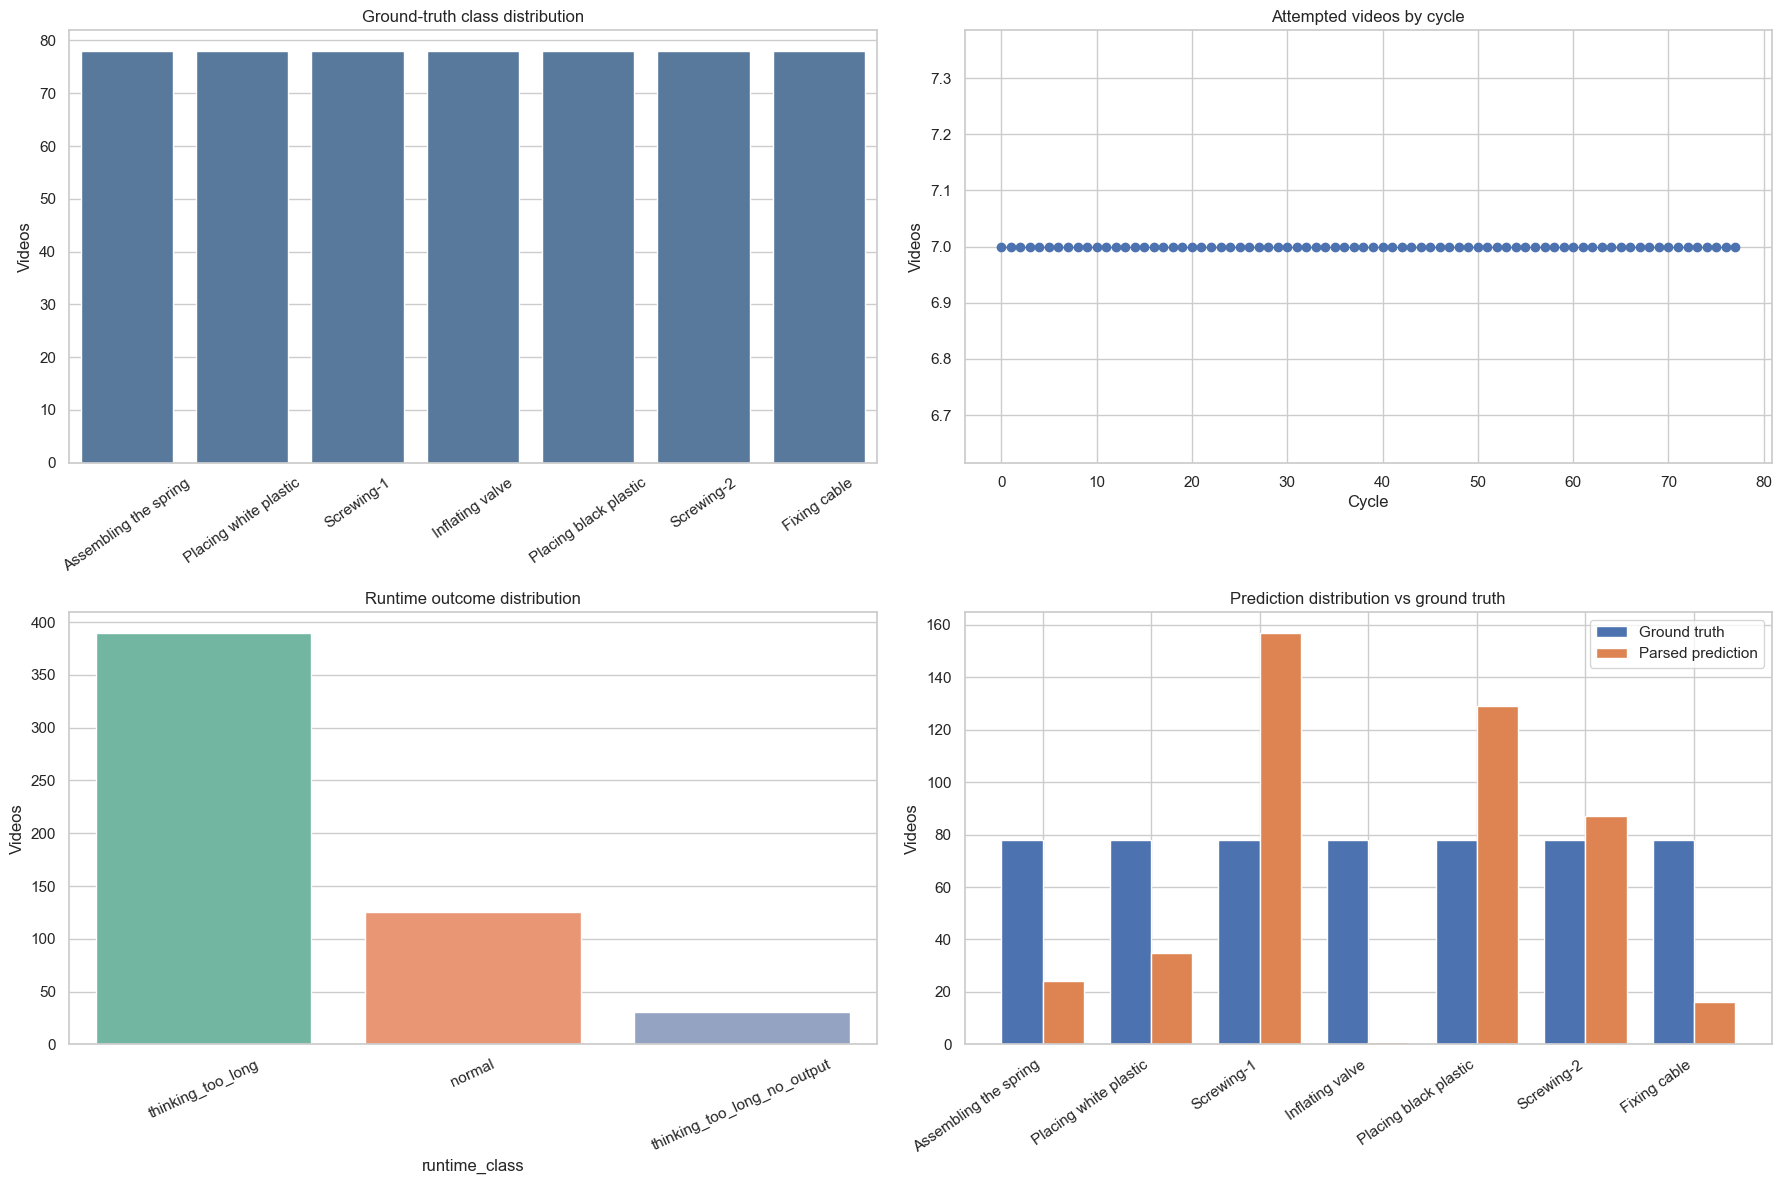

,ground_truth,parsed_prediction
Assembling the spring,NaN,NaN
Placing white plastic,NaN,NaN
Screwing-1,NaN,NaN
Inflating valve,NaN,NaN
Placing black plastic,NaN,NaN
Screwing-2,NaN,NaN
Fixing cable,NaN,NaN


In [ ]:
# Dataset, cycle, completion and prediction distributions.
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
truth_counts = df.truth.value_counts().reindex(range(7), fill_value=0)
sns.barplot(x=[TASK_NAMES[i] for i in range(7)], y=truth_counts.values, ax=axes[0,0], color='#4c78a8')
axes[0,0].set_title('Ground-truth class distribution'); axes[0,0].set_ylabel('Videos'); axes[0,0].tick_params(axis='x', rotation=35)
cycle_counts = df.cycle.value_counts().sort_index()
axes[0,1].plot(cycle_counts.index, cycle_counts.values, marker='o', linewidth=1)
axes[0,1].set_title('Attempted videos by cycle'); axes[0,1].set_xlabel('Cycle'); axes[0,1].set_ylabel('Videos')
completion_counts = df.runtime_class.value_counts()
sns.barplot(x=completion_counts.index, y=completion_counts.values, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Runtime outcome distribution'); axes[1,0].set_ylabel('Videos'); axes[1,0].tick_params(axis='x', rotation=25)
pred_counts = df.prediction.value_counts().reindex(range(7), fill_value=0)
x = np.arange(7); width = .38
axes[1,1].bar(x-width/2, truth_counts.values, width, label='Ground truth')
axes[1,1].bar(x+width/2, pred_counts.values, width, label='Parsed prediction')
axes[1,1].set_xticks(x, [TASK_NAMES[i] for i in range(7)], rotation=35, ha='right')
axes[1,1].set_title('Prediction distribution vs ground truth'); axes[1,1].set_ylabel('Videos'); axes[1,1].legend()
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'deep_distributions.png', dpi=180, bbox_inches='tight'); plt.show()
display(pd.DataFrame({'ground_truth': truth_counts, 'parsed_prediction': pred_counts}, index=[TASK_NAMES[i] for i in range(7)]))

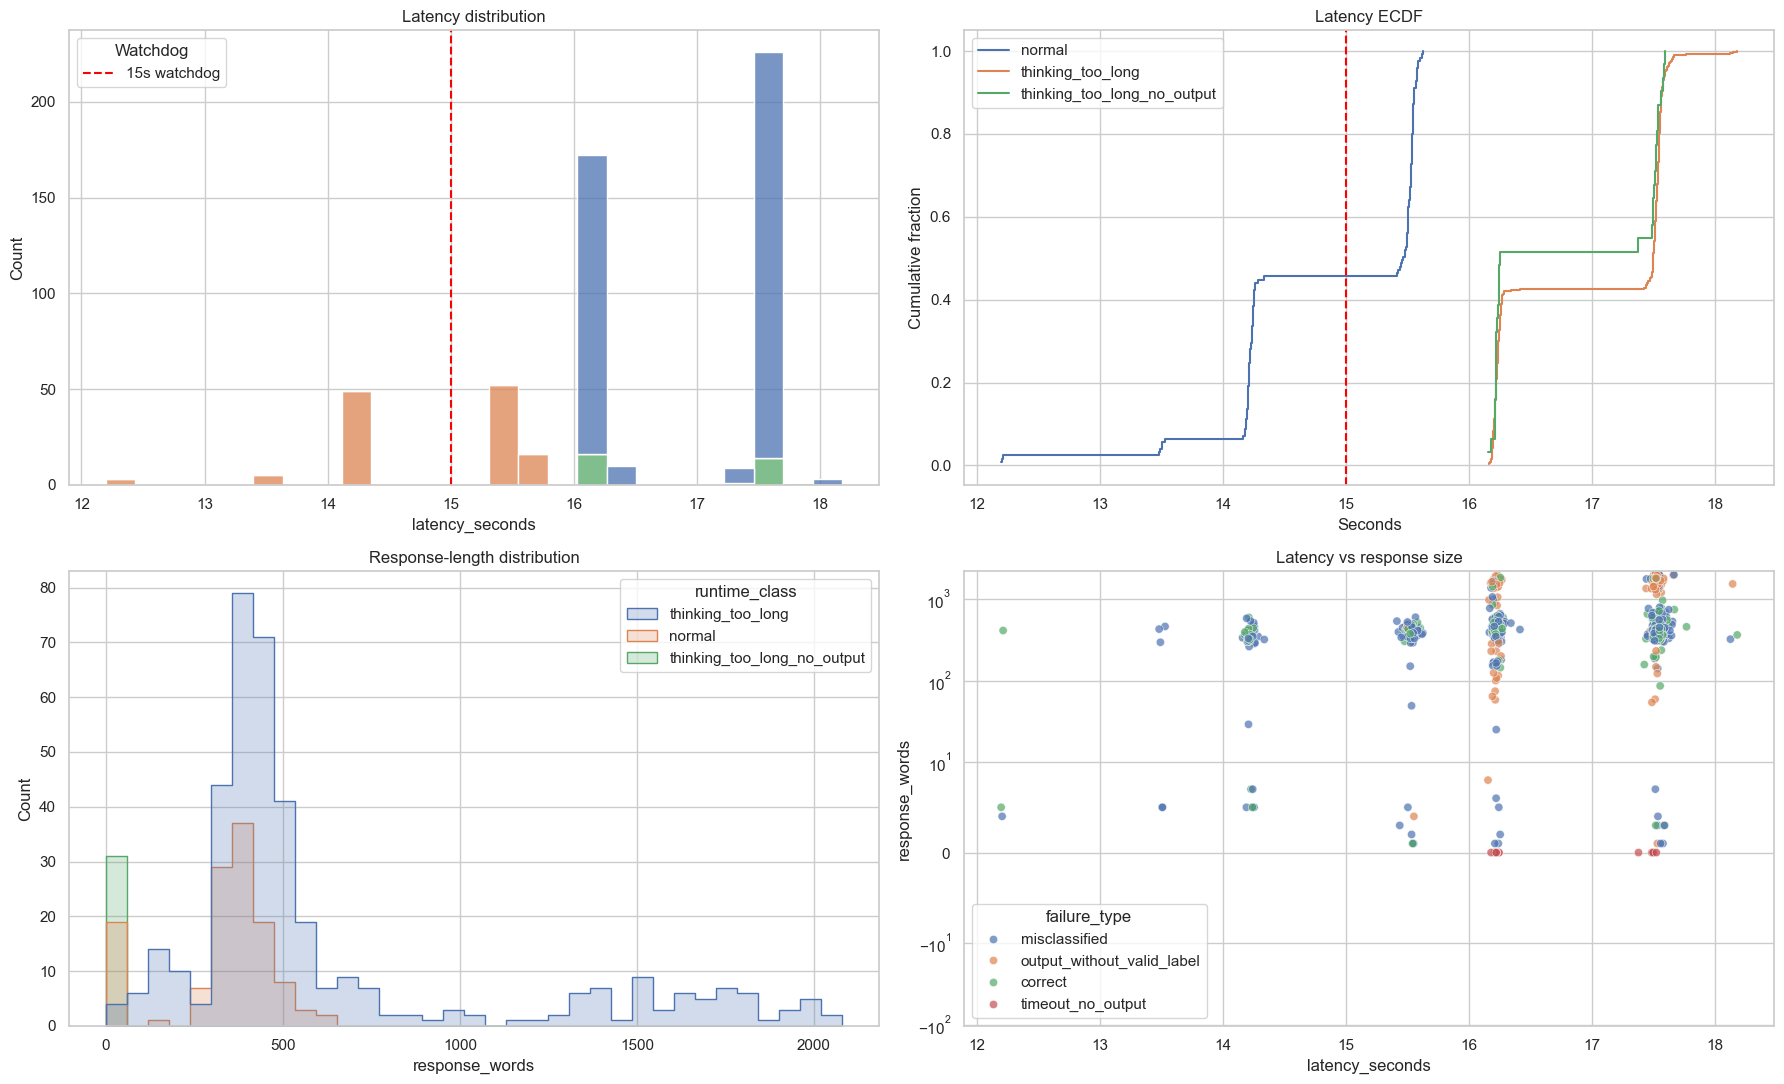

,n,latency_mean,latency_p50,latency_p95,words_median,output_rate
runtime_class,,,,,,
normal,125,14.858,15.465,15.583,365.0,1.000
thinking_too_long,390,16.986,17.498,17.595,439.5,1.000
thinking_too_long_no_output,31,16.851,16.255,17.582,0.0,0.484


In [ ]:
# Latency and response-size distributions.
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
sns.histplot(data=df, x='latency_seconds', hue='runtime_class', bins=25, multiple='stack', ax=axes[0,0])
axes[0,0].axvline(15, color='red', linestyle='--', label='15s watchdog'); axes[0,0].set_title('Latency distribution')
axes[0,0].legend(title='Watchdog')
for name, group in df.dropna(subset=['latency_seconds']).groupby('runtime_class'):
    vals = np.sort(group.latency_seconds.values); y = np.arange(1, len(vals)+1)/len(vals)
    axes[0,1].step(vals, y, where='post', label=name)
axes[0,1].axvline(15, color='red', linestyle='--'); axes[0,1].set_title('Latency ECDF'); axes[0,1].set_xlabel('Seconds'); axes[0,1].set_ylabel('Cumulative fraction'); axes[0,1].legend()
sns.histplot(data=df, x='response_words', hue='runtime_class', bins=35, element='step', ax=axes[1,0])
axes[1,0].set_title('Response-length distribution')
sns.scatterplot(data=df, x='latency_seconds', y='response_words', hue='failure_type', alpha=.7, ax=axes[1,1])
axes[1,1].set_yscale('symlog', linthresh=10); axes[1,1].set_title('Latency vs response size')
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'deep_runtime_distribution.png', dpi=180, bbox_inches='tight'); plt.show()
display(df.groupby('runtime_class').agg(n=('sample_id','size'), latency_mean=('latency_seconds','mean'), latency_p50=('latency_seconds','median'), latency_p95=('latency_seconds',lambda x:x.quantile(.95)), words_median=('response_words','median'), output_rate=('has_output','mean')).round(3))

,task,task_name,support,tp,fp,fn,precision,recall,f1
0,0,Assembling the spring,78,1,23,77,0.042,0.013,0.020
1,1,Placing white plastic,78,19,16,59,0.543,0.244,0.336
2,2,Screwing-1,78,37,120,41,0.236,0.474,0.315
3,3,Inflating valve,78,0,1,78,0.000,0.000,0.000
4,4,Placing black plastic,78,42,87,36,0.326,0.538,0.406
5,5,Screwing-2,78,22,65,56,0.253,0.282,0.267
6,6,Fixing cable,78,8,8,70,0.500,0.103,0.170


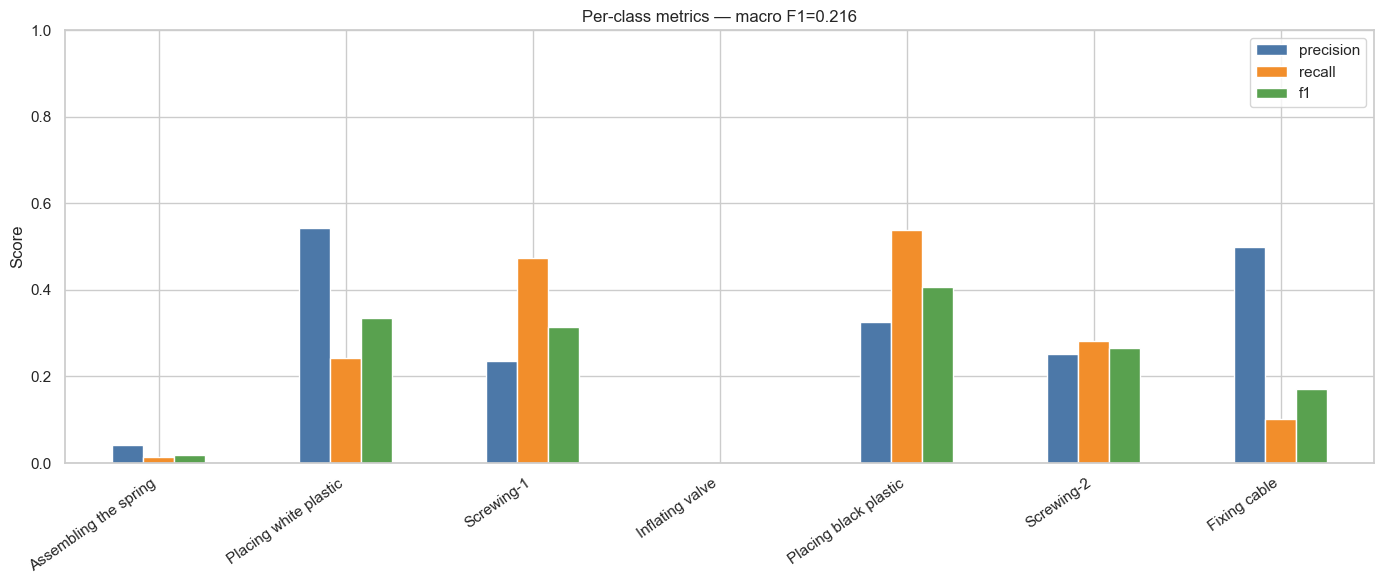

In [ ]:
# Precision, recall and F1 by class; timeout/unparseable count as missed predictions for recall.
class_rows = []
for task in range(7):
    tp = int(((df.truth==task) & (df.prediction==task)).sum())
    fp = int(((df.truth!=task) & (df.prediction==task)).sum())
    fn = int(((df.truth==task) & (df.prediction!=task)).sum())
    support = int((df.truth==task).sum())
    precision = tp/(tp+fp) if tp+fp else np.nan
    recall = tp/(tp+fn) if tp+fn else np.nan
    f1 = 2*precision*recall/(precision+recall) if precision+recall and not np.isnan(precision+recall) else 0.0
    class_rows.append({'task':task,'task_name':TASK_NAMES[task],'support':support,'tp':tp,'fp':fp,'fn':fn,'precision':precision,'recall':recall,'f1':f1})
class_metrics = pd.DataFrame(class_rows)
macro_precision = class_metrics.precision.mean()
macro_recall = class_metrics.recall.mean()
macro_f1 = class_metrics.f1.mean()
display(class_metrics.round(3))
ax = class_metrics.set_index('task_name')[['precision','recall','f1']].plot(kind='bar', figsize=(14,6), ylim=(0,1), color=['#4c78a8','#f28e2b','#59a14f'])
ax.set_title(f'Per-class metrics — macro F1={macro_f1:.3f}'); ax.set_xlabel(''); ax.set_ylabel('Score'); plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'per_class_prf1.png', dpi=180, bbox_inches='tight'); plt.show()

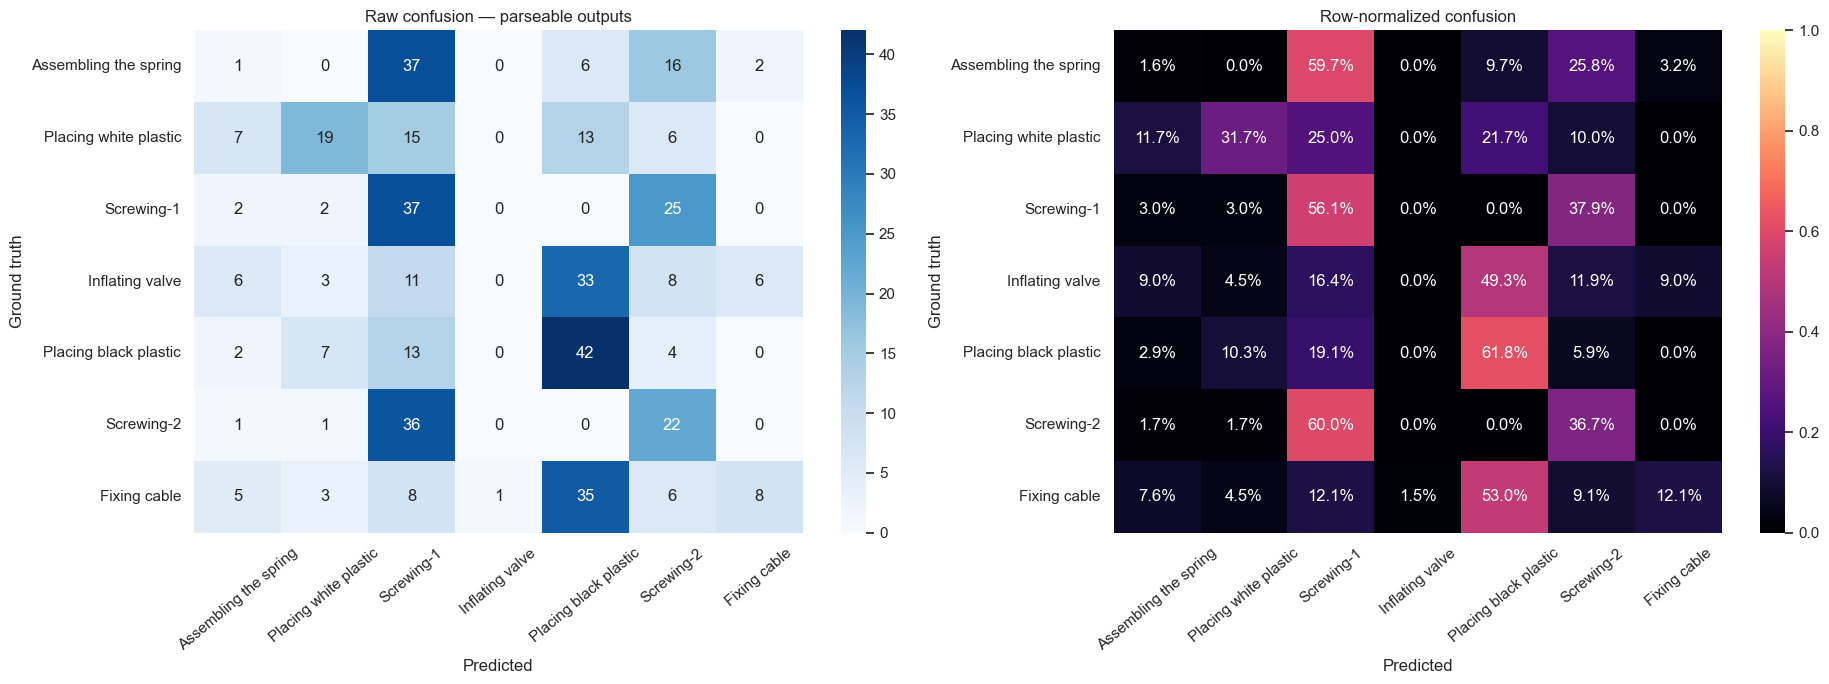

In [ ]:
# Raw and row-normalized confusion matrices.
cm_raw = pd.crosstab(df.loc[df.parseable,'truth'], df.loc[df.parseable,'prediction']).reindex(index=range(7), columns=range(7), fill_value=0)
cm_norm = cm_raw.div(cm_raw.sum(axis=1).replace(0,np.nan), axis=0).fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(19, 7))
labels = [TASK_NAMES[i] for i in range(7)]
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title('Raw confusion — parseable outputs'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Ground truth')
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='magma', vmin=0, vmax=1, ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title('Row-normalized confusion'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Ground truth')
for ax in axes: ax.tick_params(axis='x', rotation=40); ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'deep_confusion_matrices.png', dpi=180, bbox_inches='tight'); plt.show()

In [ ]:
# Bootstrap uncertainty for conditional and strict end-to-end accuracy.
rng = np.random.default_rng(20260728)
B = 5000
parse_correct = df.loc[df.parseable,'correct'].astype(float).values
all_correct = df.correct.astype(float).values
def bootstrap_mean_ci(values):
    if len(values)==0: return (np.nan,np.nan,np.nan)
    estimates = np.array([rng.choice(values, len(values), replace=True).mean() for _ in range(B)])
    return values.mean(), *np.quantile(estimates,[.025,.975])
cond_mean, cond_lo, cond_hi = bootstrap_mean_ci(parse_correct)
e2e_mean, e2e_lo, e2e_hi = bootstrap_mean_ci(all_correct)
unresolved = int((~df.parseable).sum())
optimistic_upper = (correct_n + unresolved)/attempted
uncertainty_table = pd.DataFrame([
    {'metric':'Conditional accuracy','estimate':cond_mean,'ci_low':cond_lo,'ci_high':cond_hi,'denominator':len(parse_correct)},
    {'metric':'Strict end-to-end accuracy','estimate':e2e_mean,'ci_low':e2e_lo,'ci_high':e2e_hi,'denominator':len(all_correct)},
])
display(uncertainty_table.style.format({'estimate':'{:.1%}','ci_low':'{:.1%}','ci_high':'{:.1%}'}))
display(Markdown(f'**Identification interval caused by {unresolved} unresolved outputs:** strict lower bound **{e2e_mean:.1%}**, optimistic upper bound **{optimistic_upper:.1%}**. The upper bound is not an accuracy estimate; it quantifies missing-information uncertainty.'))

,metric,estimate,ci_low,ci_high,denominator
0,Conditional accuracy,28.7%,24.7%,33.0%,449
1,Strict end-to-end accuracy,23.6%,20.1%,27.3%,546


**Identification interval caused by 97 unresolved outputs:** strict lower bound **23.6%**, optimistic upper bound **41.4%**. The upper bound is not an accuracy estimate; it quantifies missing-information uncertainty.

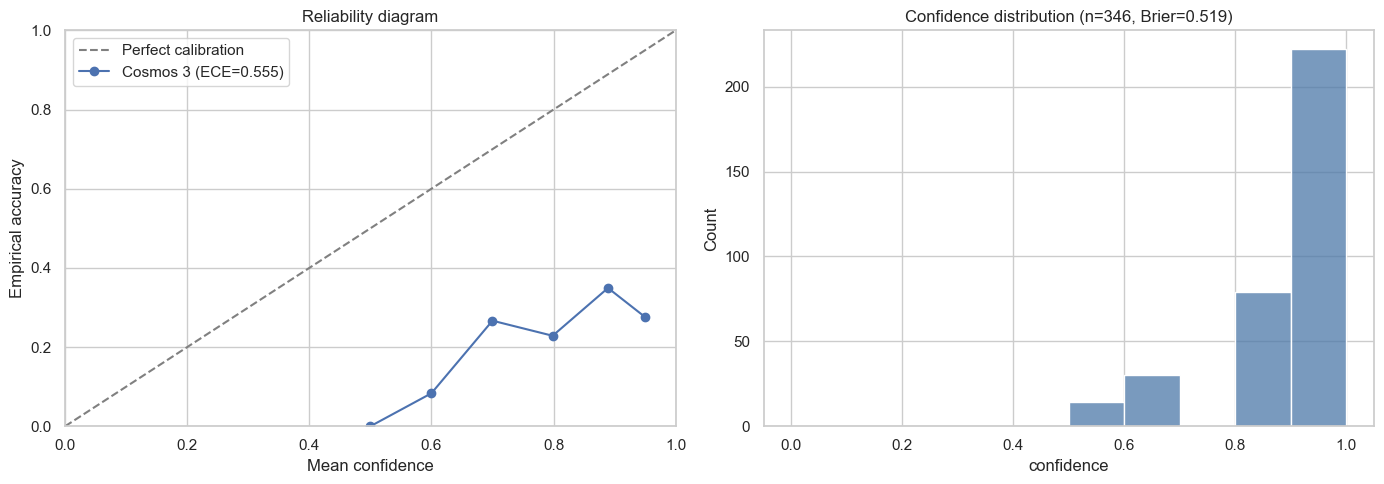

,n,mean_confidence,empirical_accuracy,weight
bin,,,,
"(0.4, 0.5]",2,0.500,0.000,0.006
"(0.5, 0.6]",12,0.600,0.083,0.035
"(0.6, 0.7]",30,0.700,0.267,0.087
"(0.7, 0.8]",35,0.799,0.229,0.101
"(0.8, 0.9]",209,0.889,0.349,0.604
"(0.9, 1.0]",58,0.950,0.276,0.168


In [ ]:
# Confidence calibration: only samples with both a parsed class and confidence are valid here.
cal = df[df.parseable & df.confidence.notna()].copy()
if len(cal):
    cal['bin'] = pd.cut(cal.confidence, bins=np.linspace(0,1,11), include_lowest=True)
    reliability = cal.groupby('bin', observed=False).agg(n=('correct','size'), mean_confidence=('confidence','mean'), empirical_accuracy=('correct','mean')).dropna(subset=['mean_confidence'])
    reliability['weight'] = reliability.n/len(cal)
    ece = float((reliability.weight * (reliability.mean_confidence-reliability.empirical_accuracy).abs()).sum())
    brier = float(np.mean((cal.confidence-cal.correct.astype(float))**2))
    fig, axes = plt.subplots(1,2,figsize=(14,5))
    axes[0].plot([0,1],[0,1],'--',color='gray',label='Perfect calibration')
    axes[0].plot(reliability.mean_confidence,reliability.empirical_accuracy,marker='o',label=f'Cosmos 3 (ECE={ece:.3f})')
    axes[0].set(xlim=(0,1),ylim=(0,1),xlabel='Mean confidence',ylabel='Empirical accuracy',title='Reliability diagram'); axes[0].legend()
    sns.histplot(cal.confidence,bins=np.linspace(0,1,11),ax=axes[1],color='#4c78a8')
    axes[1].set_title(f'Confidence distribution (n={len(cal)}, Brier={brier:.3f})')
    plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'confidence_calibration.png',dpi=180,bbox_inches='tight'); plt.show()
    display(reliability.round(3))
else:
    ece = brier = np.nan
    print('No samples contain both parseable prediction and confidence.')

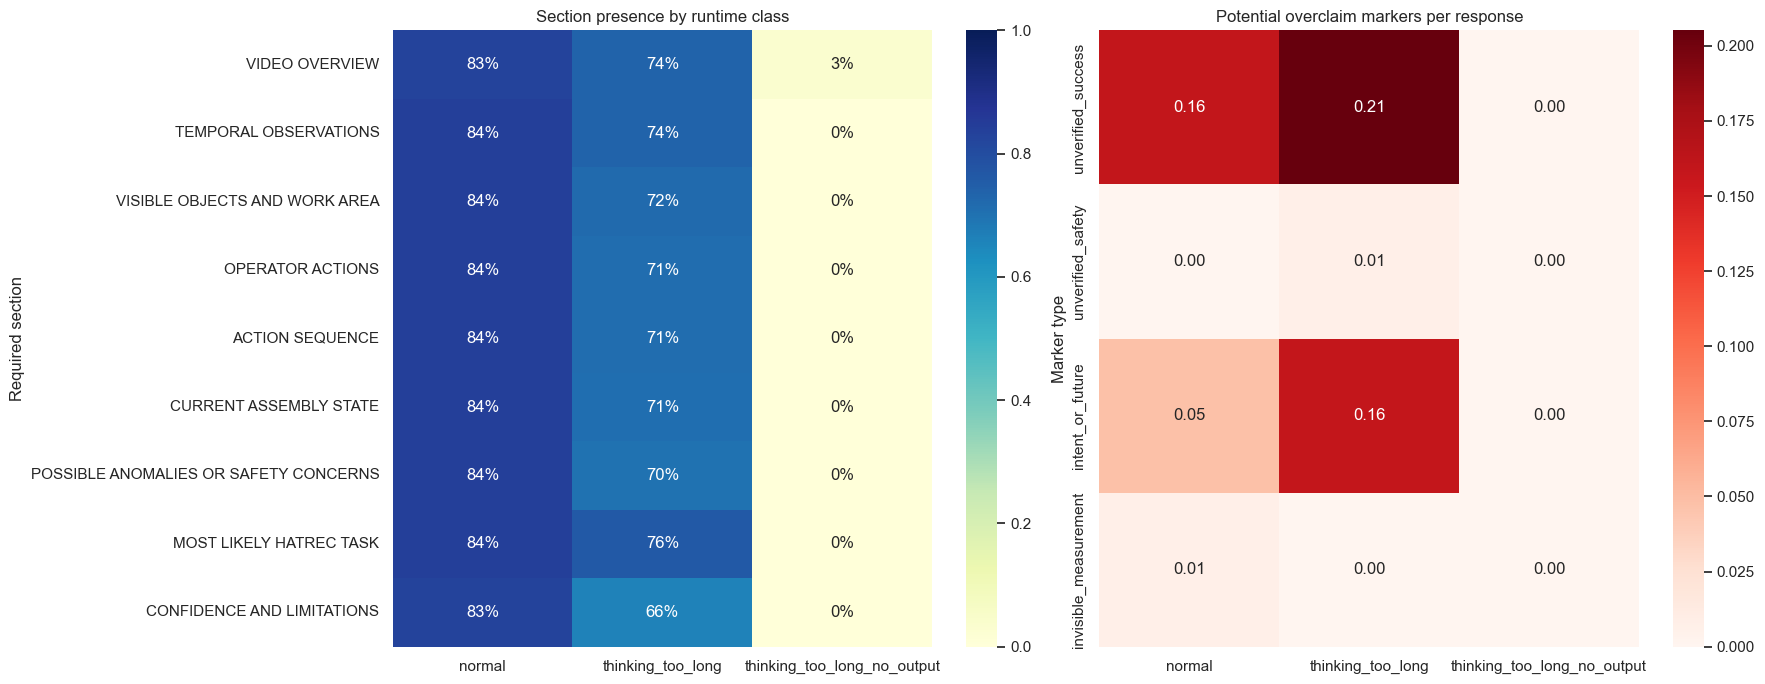

,n,sections_mean,evidence_compliance,risk_claims_mean,repetition_mean,words_median
failure_type,,,,,,
correct,129,0.842,0.380,0.233,0.058,402.0
misclassified,320,0.826,0.444,0.309,0.074,409.0
output_without_valid_label,81,0.141,0.086,0.531,0.496,1343.0
timeout_no_output,16,0.000,0.000,0.000,0.000,0.0


In [ ]:
# Section-level format compliance and evidence-grounding indicators.
section_matrix = pd.DataFrame({section: df.report.str.upper().str.contains(section, regex=False) for section in SECTIONS})
section_matrix['runtime_class'] = df.runtime_class.values
section_rates = section_matrix.groupby('runtime_class').mean().T
fig, axes = plt.subplots(1,2,figsize=(18,7))
sns.heatmap(section_rates,annot=True,fmt='.0%',cmap='YlGnBu',vmin=0,vmax=1,ax=axes[0])
axes[0].set_title('Section presence by runtime class'); axes[0].set_xlabel(''); axes[0].set_ylabel('Required section')
risk_rates = df.groupby('runtime_class')[list(RISK_PATTERNS)].mean().T
sns.heatmap(risk_rates,annot=True,fmt='.2f',cmap='Reds',ax=axes[1])
axes[1].set_title('Potential overclaim markers per response'); axes[1].set_xlabel(''); axes[1].set_ylabel('Marker type')
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'format_and_grounding_audit.png',dpi=180,bbox_inches='tight'); plt.show()
quality_by_outcome = df.groupby('failure_type').agg(n=('sample_id','size'),sections_mean=('section_fraction','mean'),evidence_compliance=('evidence_tag_compliant','mean'),risk_claims_mean=('risk_claim_count','mean'),repetition_mean=('repetition_ratio','mean'),words_median=('response_words','median')).round(3)
display(quality_by_outcome)

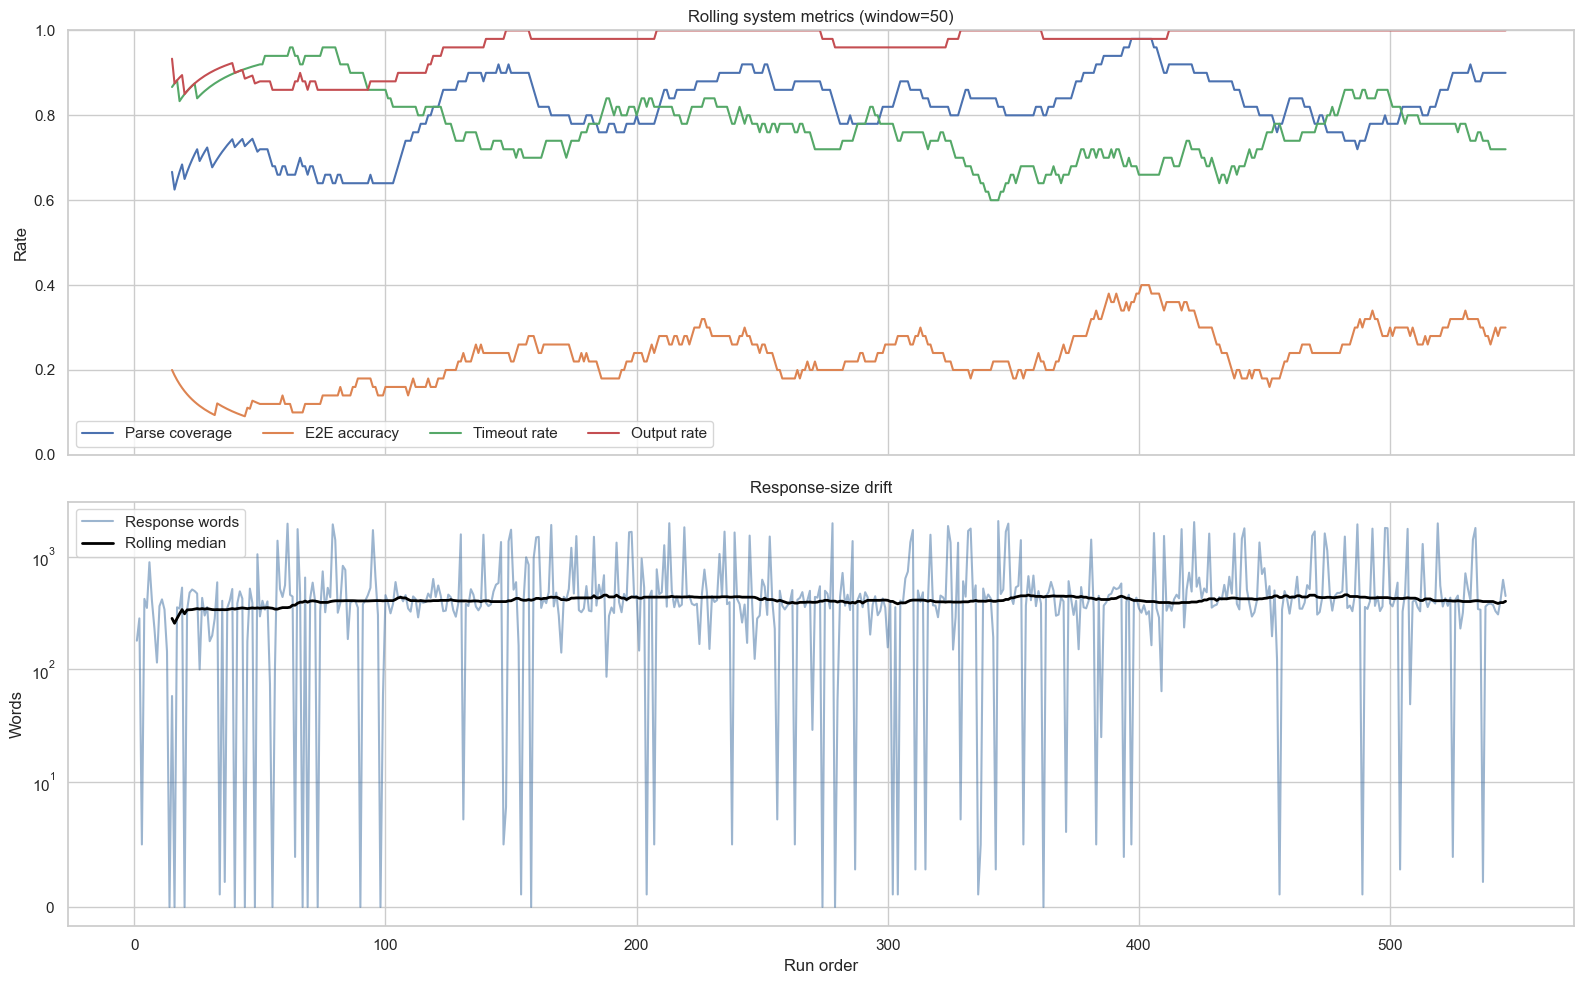

,n,timeout_rate,output_rate,parse_coverage,e2e_accuracy,median_words
run_third,,,,,,
first,182,0.830,0.929,0.764,0.181,402.5
middle,182,0.742,0.984,0.841,0.236,419.0
last,182,0.742,1.000,0.863,0.291,413.5


In [ ]:
# Run-order drift: detects UI/backend degradation, warming or timeout bursts.
ordered = df.sort_values('attempt_order').copy()
window = 50
ordered['rolling_parse_coverage'] = ordered.parseable.rolling(window,min_periods=15).mean()
ordered['rolling_e2e_accuracy'] = ordered.correct.rolling(window,min_periods=15).mean()
ordered['rolling_timeout_rate'] = ordered.is_timeout.rolling(window,min_periods=15).mean()
ordered['rolling_output_rate'] = ordered.has_output.rolling(window,min_periods=15).mean()
fig, axes = plt.subplots(2,1,figsize=(16,10),sharex=True)
for col,label in [('rolling_parse_coverage','Parse coverage'),('rolling_e2e_accuracy','E2E accuracy'),('rolling_timeout_rate','Timeout rate'),('rolling_output_rate','Output rate')]:
    axes[0].plot(ordered.attempt_order,ordered[col],label=label)
axes[0].set_ylim(0,1); axes[0].set_title(f'Rolling system metrics (window={window})'); axes[0].set_ylabel('Rate'); axes[0].legend(ncol=4)
axes[1].plot(ordered.attempt_order,ordered.response_words,color='#4c78a8',alpha=.55,label='Response words')
axes[1].plot(ordered.attempt_order,ordered.response_words.rolling(window,min_periods=15).median(),color='black',linewidth=2,label='Rolling median')
axes[1].set_yscale('symlog',linthresh=10); axes[1].set_title('Response-size drift'); axes[1].set_xlabel('Run order'); axes[1].set_ylabel('Words'); axes[1].legend()
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'run_order_drift.png',dpi=180,bbox_inches='tight'); plt.show()
ordered['run_third'] = pd.qcut(ordered.attempt_order.rank(method='first'),3,labels=['first','middle','last'])
display(ordered.groupby('run_third',observed=True).agg(n=('sample_id','size'),timeout_rate=('is_timeout','mean'),output_rate=('has_output','mean'),parse_coverage=('parseable','mean'),e2e_accuracy=('correct','mean'),median_words=('response_words','median')).round(3))

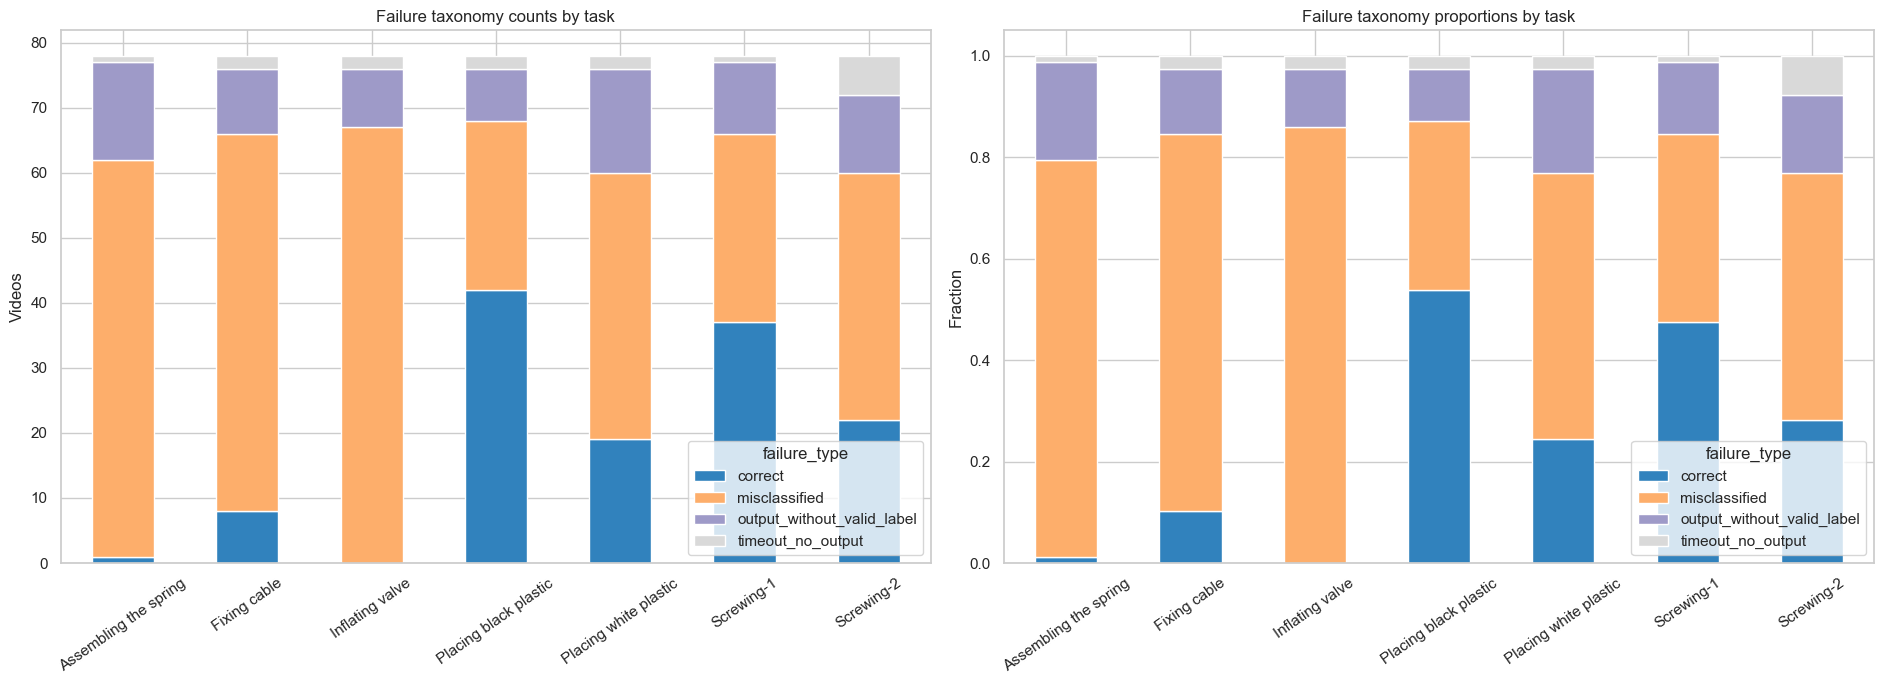

failure_type,correct,misclassified,output_without_valid_label,timeout_no_output
truth_name,,,,
Assembling the spring,1,61,15,1
Fixing cable,8,58,10,2
Inflating valve,0,67,9,2
Placing black plastic,42,26,8,2
Placing white plastic,19,41,16,2
Screwing-1,37,29,11,1
Screwing-2,22,38,12,6


In [ ]:
# Error taxonomy by ground-truth class.
error_by_task = pd.crosstab(df.truth_name,df.failure_type).reindex(columns=['correct','misclassified','output_without_valid_label','timeout_no_output'],fill_value=0)
error_rate_by_task = error_by_task.div(error_by_task.sum(axis=1),axis=0)
fig, axes = plt.subplots(1,2,figsize=(19,7))
error_by_task.plot(kind='bar',stacked=True,ax=axes[0],colormap='tab20c')
axes[0].set_title('Failure taxonomy counts by task'); axes[0].set_xlabel(''); axes[0].set_ylabel('Videos'); axes[0].tick_params(axis='x',rotation=35)
error_rate_by_task.plot(kind='bar',stacked=True,ax=axes[1],colormap='tab20c')
axes[1].set_title('Failure taxonomy proportions by task'); axes[1].set_xlabel(''); axes[1].set_ylabel('Fraction'); axes[1].tick_params(axis='x',rotation=35)
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT/'failure_taxonomy.png',dpi=180,bbox_inches='tight'); plt.show()
display(error_by_task)

In [ ]:
# Automatic deep-insight summary and export.
dominant_pred = int(pred_counts.idxmax()) if pred_counts.sum() else None
dominant_share = float(pred_counts.max()/pred_counts.sum()) if pred_counts.sum() else np.nan
best_task = class_metrics.sort_values('recall',ascending=False).iloc[0]
worst_task = class_metrics.sort_values('recall',ascending=True).iloc[0]
truth_prob = truth_counts/truth_counts.sum()
pred_prob = pred_counts/pred_counts.sum() if pred_counts.sum() else pred_counts.astype(float)
total_variation = float(0.5*np.abs(truth_prob-pred_prob).sum()) if pred_counts.sum() else np.nan
advanced = {
    **insights, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'conditional_accuracy_ci95': [cond_lo,cond_hi], 'e2e_accuracy_ci95': [e2e_lo,e2e_hi],
    'optimistic_unresolved_upper_bound': optimistic_upper, 'confidence_ece': None if np.isnan(ece) else ece,
    'confidence_brier': None if np.isnan(brier) else brier, 'prediction_total_variation': total_variation,
    'dominant_prediction': None if dominant_pred is None else TASK_NAMES[dominant_pred], 'dominant_prediction_share': dominant_share,
}
class_metrics.to_csv(ANALYSIS_ROOT/'deep_per_class_metrics.csv',index=False)
error_by_task.to_csv(ANALYSIS_ROOT/'deep_error_taxonomy.csv')
section_rates.to_csv(ANALYSIS_ROOT/'deep_section_compliance.csv')
(ANALYSIS_ROOT/'deep_audit_summary.json').write_text(json.dumps(advanced,indent=2),encoding='utf-8')
display(Markdown(f'''# Deep-audit findings
1. **System completion:** {normal_n}/{attempted} ({normal_n/attempted:.1%}) completed normally; {too_long_n}/{attempted} ({too_long_n/attempted:.1%}) exceeded the 15-second watchdog.
2. **Strict model-system score:** end-to-end accuracy is {e2e_mean:.1%} (bootstrap 95% CI {e2e_lo:.1%}–{e2e_hi:.1%}).
3. **Conditional classification:** among parseable outputs, accuracy is {cond_mean:.1%} (95% CI {cond_lo:.1%}–{cond_hi:.1%}); macro F1 is {macro_f1:.3f}.
4. **Prediction bias:** the dominant parsed class is **{TASK_NAMES.get(dominant_pred)}** ({dominant_share:.1%} of parsed outputs); distribution distance from the balanced truth prior is TV={total_variation:.3f}.
5. **Class extremes:** highest recall is **{best_task.task_name}** ({best_task.recall:.1%}); lowest is **{worst_task.task_name}** ({worst_task.recall:.1%}).
6. **Output contract:** full 9-section compliance is {df.full_format.mean():.1%}; explicit OBSERVED/INFERRED/UNKNOWN tagging is {df.evidence_tag_compliant.mean():.1%}.
7. **Interpretation constraint:** because {unresolved}/{attempted} outputs are unparseable, conditional accuracy alone overstates deployed performance. The 15-second watchdog measures a latency-constrained system, not unlimited-time Cosmos 3 capability.
'''))
print('Deep audit exported to', ANALYSIS_ROOT)

# Deep-audit findings
1. **System completion:** 125/546 (22.9%) completed normally; 421/546 (77.1%) exceeded the 15-second watchdog.
2. **Strict model-system score:** end-to-end accuracy is 23.6% (bootstrap 95% CI 20.1%–27.3%).
3. **Conditional classification:** among parseable outputs, accuracy is 28.7% (95% CI 24.7%–33.0%); macro F1 is 0.216.
4. **Prediction bias:** the dominant parsed class is **Screwing-1** (35.0% of parsed outputs); distribution distance from the balanced truth prior is TV=0.402.
5. **Class extremes:** highest recall is **Placing black plastic** (53.8%); lowest is **Inflating valve** (0.0%).
6. **Output contract:** full 9-section compliance is 65.9%; explicit OBSERVED/INFERRED/UNKNOWN tagging is 36.3%.
7. **Interpretation constraint:** because 97/546 outputs are unparseable, conditional accuracy alone overstates deployed performance. The 15-second watchdog measures a latency-constrained system, not unlimited-time Cosmos 3 capability.


Deep audit exported to c:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision\research\hatrec_cosmos3\outputs\analysis
